# 01 - Carga y estructura de los datos

Objetivo: cargar `data/Customer_Data.csv`, validar estructura basica y dejar clara la variable objetivo antes del EDA y el modelado.

Este notebook confirma el grano del dataset: una fila por cliente.

In [1]:
import pandas as pd

DATA_PATH = "../data/Customer_Data.csv"
TARGET_COL = "Customer_Status"
CUSTOMER_ID_COL = "Customer_ID"

df = pd.read_csv(DATA_PATH)

print(f"Filas: {df.shape[0]}, columnas: {df.shape[1]}")
df.head()

Filas: 6418, columnas: 32


,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,19877-DEL,Male,35,No,Delhi,7,27,NaN,Yes,No,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,58353-MAH,Female,45,Yes,Maharashtra,14,13,NaN,Yes,Yes,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,25063-WES,Male,51,No,West Bengal,4,35,Deal 5,Yes,No,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,59787-KAR,Male,79,No,Karnataka,3,21,Deal 4,Yes,No,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,28544-TAM,Female,80,No,Tamil Nadu,3,8,NaN,Yes,No,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


## Tipos de dato y nulos

In [2]:
df.dtypes.value_counts()

str        23
float64     5
int64       4
Name: count, dtype: int64

In [3]:
nulls = df.isna().sum()
nulls[nulls > 0].sort_values(ascending=False)

Churn_Category            4686
Churn_Reason              4686
Value_Deal                3548
Internet_Type             1390
Online_Security           1390
Online_Backup             1390
Device_Protection_Plan    1390
Premium_Support           1390
Streaming_TV              1390
Streaming_Movies          1390
Streaming_Music           1390
Unlimited_Data            1390
Multiple_Lines             622
dtype: int64

Los nulos en columnas de servicio se revisan en `02_eda.ipynb`. No se tratan como error automaticamente porque dependen de si el cliente tiene o no servicio de internet.

## Variable objetivo: `Customer_Status`

`Customer_Status` tiene tres valores: `Stayed`, `Churned` y `Joined`.

Para entrenar el modelo solo se usan `Stayed` y `Churned`, porque tienen desenlace conocido. Los clientes `Joined` se reservan para scoring en `09_business_insights.ipynb`.

In [4]:
df[TARGET_COL].value_counts()

Customer_Status
Stayed     4275
Churned    1732
Joined      411
Name: count, dtype: int64

## Distribucion visual de `Customer_Status`

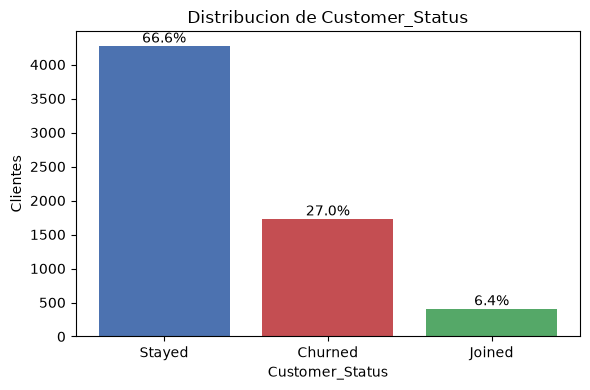

In [5]:
import matplotlib.pyplot as plt

status_counts = df[TARGET_COL].value_counts()
status_pct = df[TARGET_COL].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))
bars = plt.bar(status_counts.index, status_counts.values, color=["#4C72B0", "#C44E52", "#55A868"])
for bar, pct in zip(bars, status_pct.reindex(status_counts.index)):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{pct:.1f}%", ha="center", va="bottom")
plt.title("Distribucion de Customer_Status")
plt.xlabel("Customer_Status")
plt.ylabel("Clientes")
plt.tight_layout()
plt.show()

In [6]:
df_model = df[df[TARGET_COL].isin(["Stayed", "Churned"])].copy()
df_joined = df[df[TARGET_COL] == "Joined"].copy()

print(f"df_model  (Stayed/Churned, para entrenar/evaluar): {df_model.shape[0]} filas")
print(f"df_joined (Joined, se puntuan al final):           {df_joined.shape[0]} filas")

df_model  (Stayed/Churned, para entrenar/evaluar): 6007 filas
df_joined (Joined, se puntuan al final):           411 filas


## Duplicados

In [7]:
print(f"Customer_ID duplicados: {df[CUSTOMER_ID_COL].duplicated().sum()}")

Customer_ID duplicados: 0
